#Importing all the necessary libraries

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


#Making the building blocks

In [ ]:

# ==========================================
# 1. CORE BUILDING BLOCKS (FROM SCRATCH)
# ==========================================

# Positional Encoding: Adds information about the relative or absolute position of the tokens in the sequence.
# This is crucial for Transformers as they do not inherently process sequences in order.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        # Create a positional encoding matrix 'pe' of shape (max_len, d_model)
        pe = torch.zeros(max_len, d_model)
        # 'position' vector for each token's index
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        # 'div_term' for the sinusoidal functions (sin for even, cos for odd indices)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        # Apply sin to even indices in d_model dimension
        pe[:, 0::2] = torch.sin(position * div_term)
        # Apply cos to odd indices in d_model dimension
        pe[:, 1::2] = torch.cos(position * div_term)
        # Register 'pe' as a buffer, meaning it's part of the module's state but not a learnable parameter
        self.register_buffer('pe', pe.unsqueeze(0)) # unsqueeze(0) for batch dimension

    def forward(self, x):
        # Add the positional encoding to the input embeddings
        # x.size(1) ensures that the positional encoding matches the current sequence length
        return x + self.pe[:, :x.size(1)]


# Multi-Head Attention: Allows the model to jointly attend to information from different representation
# subspaces at different positions. It's a combination of several attention layers.
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        # d_k is the dimension of the query, key, and value vectors for each head
        self.d_k = d_model // n_heads

        # Linear layers for transforming input to Query, Key, and Value vectors
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        # Final linear layer to combine outputs from all heads
        self.fc = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # 1. Linear projections and split into heads
        # The input (batch_size, seq_len, d_model) is projected, then reshaped to (batch_size, n_heads, seq_len, d_k)
        Q = self.w_q(q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        # 2. Scaled Dot-Product Attention
        # Calculate attention scores: (Q * K^T) / sqrt(d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # Apply mask (e.g., causal mask for decoders) by filling masked positions with a very small number
        if mask is not None:
            # Handle both 2D (causal) and 4D masks by broadcasting
            scores = scores.masked_fill(mask == 0, -1e9)

        # Apply softmax to get attention weights
        attn = F.softmax(scores, dim=-1)
        # Multiply attention weights by Value vectors to get context vectors
        context = torch.matmul(attn, V)
        # Concatenate outputs from all heads: Transpose back and reshape
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        # Apply final linear layer
        return self.fc(context)


# FeedForward Network: A simple fully connected feed-forward network applied to each position separately and identically.
# It consists of two linear transformations with a ReLU activation in between.
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=512):
        super().__init__()
        # First linear layer: d_model -> d_ff (expansion)
        self.fc1 = nn.Linear(d_model, d_ff)
        # Second linear layer: d_ff -> d_model (projection back to original dimension)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        # Apply first linear layer, ReLU activation, then second linear layer
        return self.fc2(F.relu(self.fc1(x)))

# ==========================================
# 2. TRANSFORMER VARIANTS
# ==========================================


In [ ]:



# --- VARIANT 1: ENCODER ONLY (BERT-Style) ---
# EncoderBlock: Represents a single block in the Transformer Encoder. It consists of a MultiHeadAttention layer
# followed by a FeedForward network, with Layer Normalization and Residual Connections applied after each sub-layer.
class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # Apply MultiHeadAttention with residual connection and layer normalization
        x = self.norm1(x + self.attn(x, x, x, mask))
        # Apply FeedForward network with residual connection and layer normalization
        x = self.norm2(x + self.ff(x))
        return x

# MedicalClassifier: An Encoder-Only Transformer model for classification tasks, similar to BERT.
# It processes an input sequence and outputs a classification score.
class MedicalClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, n_classes):
        super().__init__()
        # Embedding layer to convert token IDs to dense vectors
        self.embedding = nn.Embedding(vocab_size, d_model)
        # Positional Encoding to add sequence order information
        self.pos_enc = PositionalEncoding(d_model)
        # Stack of EncoderBlocks
        self.layers = nn.ModuleList([EncoderBlock(d_model, n_heads) for _ in range(n_layers)])
        # Final linear layer for classification
        self.fc = nn.Linear(d_model, n_classes)

    def forward(self, x):
        # Apply embedding and positional encoding
        x = self.pos_enc(self.embedding(x))
        # Pass through each EncoderBlock
        for layer in self.layers:
            x = layer(x)
        # Average pooling across the sequence dimension and then pass through the classifier head
        return self.fc(x.mean(dim=1))


In [ ]:


# --- VARIANT 2: DECODER ONLY (GPT-Style) ---
# MedicalGPT: A Decoder-Only Transformer model designed for generative tasks, similar to GPT.
# It predicts the next token in a sequence, taking into account previously generated tokens.
class MedicalGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads):
        super().__init__()
        # Embedding layer for token representations
        self.embedding = nn.Embedding(vocab_size, d_model)
        # Positional Encoding to add sequence order information
        self.pos_enc = PositionalEncoding(d_model)
        # Stack of Decoder-like EncoderBlocks. Note: For a true Decoder-Only architecture
        # these 'EncoderBlocks' would internally implement masked self-attention.
        self.layers = nn.ModuleList([EncoderBlock(d_model, n_heads) for _ in range(n_layers)])
        # Final linear layer to project back to vocabulary size for token prediction
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        seq_len = x.size(1)
        # Create a causal mask (look-ahead mask) to prevent tokens from attending to future tokens.
        # This is essential for generative models to maintain the auto-regressive property.
        mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)
        # Apply embedding and positional encoding
        x = self.pos_enc(self.embedding(x))
        # Pass through each EncoderBlock, applying the causal mask to self-attention
        for layer in self.layers:
            x = layer(x, mask)
        # Project output to vocabulary space for next token prediction
        return self.fc(x)



In [ ]:


# --- VARIANT 3: ENCODER-DECODER (T5-Style) ---
# EncoderDecoderBlock: Represents a single block in the Transformer Decoder for sequence-to-sequence models.
# It includes masked self-attention, cross-attention (attending to encoder output), and a FeedForward network.
class EncoderDecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        # Self attention (with causal mask) on the decoder input
        x = self.norm1(x + self.self_attn(x, x, x, tgt_mask))
        # Cross attention (queries from decoder, keys/values from encoder output)
        x = self.norm2(x + self.cross_attn(x, enc_output, enc_output, src_mask))
        # FeedForward network
        x = self.norm3(x + self.ff(x))
        return x

# MedicalSummarizer: An Encoder-Decoder Transformer model for sequence-to-sequence tasks,
# such as summarization or translation, similar to T5.
class MedicalSummarizer(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads):
        super().__init__()
        # Embedding layer for both source and target tokens
        self.embedding = nn.Embedding(vocab_size, d_model)
        # Positional Encoding for sequence order information
        self.pos_enc = PositionalEncoding(d_model)
        # Stack of EncoderBlocks for the encoder part
        self.encoder_layers = nn.ModuleList([EncoderBlock(d_model, n_heads) for _ in range(n_layers)])
        # Stack of EncoderDecoderBlocks for the decoder part
        self.decoder_layers = nn.ModuleList([EncoderDecoderBlock(d_model, n_heads) for _ in range(n_layers)])
        # Final linear layer to project decoder output to vocabulary size for token prediction
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt):
        # Encode the source sequence
        enc_out = self.pos_enc(self.embedding(src))
        for layer in self.encoder_layers:
            enc_out = layer(enc_out)

        # Decode the target sequence
        tgt_seq_len = tgt.size(1)
        # Create a causal mask for the decoder's self-attention to prevent looking ahead
        tgt_mask = torch.tril(torch.ones(tgt_seq_len, tgt_seq_len)).unsqueeze(0).unsqueeze(0)

        dec_out = self.pos_enc(self.embedding(tgt))
        for layer in self.decoder_layers:
            # Pass encoder output as key/value to the decoder's cross-attention
            dec_out = layer(dec_out, enc_out, tgt_mask=tgt_mask)

        return self.fc(dec_out)


In [ ]:

# ==========================================
# 3. TOKENIZER & DATASET
# ==========================================

# SimpleTokenizer: A basic tokenizer to convert text into numerical tokens.
# It creates a vocabulary from a given corpus and provides methods to encode text.
class SimpleTokenizer:
    def __init__(self, corpus):
        # Initialize vocabulary with special tokens for padding, start of sequence, end of sequence, and unknown words.
        self.vocab = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        # Build vocabulary from the corpus, assigning a unique ID to each word.
        words = sorted(list(set(" ".join(corpus).split())))
        for i, word in enumerate(words):
            self.vocab[word] = i + 4
        # Create an inverse vocabulary to convert IDs back to words (for decoding).
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    def encode(self, text, max_len=20):
        # Convert text into a sequence of token IDs. Unknown words default to '<UNK>' token (ID 3).
        tokens = [self.vocab.get(w, 3) for w in text.split()]
        # Truncate or pad the token sequence to a fixed maximum length.
        tokens = tokens[:max_len]
        return tokens + [0] * (max_len - len(tokens))

# Medical corpus: A small dataset of medical phrases used for demonstration and training of the Transformer models.
medical_corpus = [
    "patient presents with acute headache and nausea",
    "prescribe ibuprofen for minor muscle pain",
    "emergency trauma in lower abdomen area",
    "routine checkup for diabetic patient management",
    "severe chest pain radiating to left arm",
    "apply bandage to the clean wound",
    "symptoms include high fever and dry cough",
    "administer saline drip for dehydration"
]


In [ ]:

# ==========================================
# 4. GRAPH GENERATION
# ==========================================

def create_graphs(epochs_dec, losses_dec, epochs_seq2seq, losses_seq2seq):
    """Create visualization graphs for all three experiments."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Transformer Variants: Training Loss Curves', fontsize=16, fontweight='bold')

    # # Graph 1: Encoder-Only (Triage)
    # axes[0, 0].plot(epochs_enc, losses_enc, 'b-', linewidth=2, label='Encoder-Only')
    # axes[0, 0].set_title('Experiment 1: Encoder-Only (Triage)', fontweight='bold')
    # axes[0, 0].set_xlabel('Epoch')
    # axes[0, 0].set_ylabel('Loss')
    # axes[0, 0].grid(True, alpha=0.3)
    # axes[0, 0].legend()

    # Graph 2: Decoder-Only (Generation)
    axes[0, 1].plot(epochs_dec, losses_dec, 'r-', linewidth=2, label='Decoder-Only')
    axes[0, 1].set_title('Experiment 2: Decoder-Only (Generation)', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Graph 3: Encoder-Decoder (Simplification)
    axes[1, 0].plot(epochs_seq2seq, losses_seq2seq, 'g-', linewidth=2, label='Encoder-Decoder')
    axes[1, 0].set_title('Experiment 3: Encoder-Decoder (Simplification)', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Graph 4: Combined comparison
    # axes[1, 1].plot(epochs_enc, losses_enc, 'b-', linewidth=2, label='Encoder-Only', alpha=0.8)
    axes[1, 1].plot(epochs_dec, losses_dec, 'r-', linewidth=2, label='Decoder-Only', alpha=0.8)
    axes[1, 1].plot(epochs_seq2seq, losses_seq2seq, 'g-', linewidth=2, label='Encoder-Decoder', alpha=0.8)
    axes[1, 1].set_title('All Experiments Comparison', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
    print("\nGraphs saved as 'training_curves.png'")
    plt.show()


In [ ]:

# ==========================================
# 5. RUNNING EXPERIMENTS
# ==========================================

def run_experiments():
    tokenizer = SimpleTokenizer(medical_corpus)
    vocab_size = len(tokenizer.vocab)
    device = torch.device("cpu")

    print(f"Vocab Size: {vocab_size}")

    # Pre-process data
    src_data = torch.stack([torch.tensor(tokenizer.encode(s)) for s in medical_corpus])

    # --- 1. Encoder-Only ---
    # print("\n--- Experiment 1: Encoder-Only (Triage) ---")
    # model_enc = MedicalClassifier(vocab_size, 128, 2, 4, 2)
    # labels = torch.tensor([1 if ("emergency" in s or "chest" in s) else 0 for s in medical_corpus])
    # optimizer = torch.optim.Adam(model_enc.parameters(), lr=0.001)

    # losses_enc = []
    # epochs_enc = []

    # for epoch in range(51):
    #     output = model_enc(src_data)
    #     loss = F.cross_entropy(output, labels)
    #     optimizer.zero_grad(); loss.backward(); optimizer.step()
    #     losses_enc.append(loss.item())
    #     epochs_enc.append(epoch)
    #     if epoch % 10 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    # --- 2. Decoder-Only ---
    print("\n--- Experiment 2: Decoder-Only (Generation) ---")
    model_dec = MedicalGPT(vocab_size, 128, 2, 4)
    optimizer = torch.optim.Adam(model_dec.parameters(), lr=0.001)

    losses_dec = []
    epochs_dec = []

    for epoch in range(41):
        output = model_dec(src_data)
        # Shift targets for next-token prediction
        loss = F.cross_entropy(output[:, :-1, :].reshape(-1, vocab_size), src_data[:, 1:].reshape(-1))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses_dec.append(loss.item())
        epochs_dec.append(epoch)
        if epoch % 20 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    # --- 3. Encoder-Decoder ---
    print("\n--- Experiment 3: Encoder-Decoder (Simplification) ---")
    model_seq2seq = MedicalSummarizer(vocab_size, 128, 2, 4)
    optimizer = torch.optim.Adam(model_seq2seq.parameters(), lr=0.001)

    # Task: Map full sentence to first 5 words (Simplification)
    # We use .clone().detach() to avoid stride issues
    target_data = src_data[:, :8].clone().detach()

    losses_seq2seq = []
    epochs_seq2seq = []

    for epoch in range(41):
        optimizer.zero_grad()
        output = model_seq2seq(src_data, target_data)
        # Use .reshape instead of .view to avoid the error you saw
        loss = F.cross_entropy(output.reshape(-1, vocab_size), target_data.reshape(-1))
        loss.backward(); optimizer.step()
        losses_seq2seq.append(loss.item())
        epochs_seq2seq.append(epoch)
        if epoch % 20 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    print("\nAll experiments completed successfully on CPU.")

    # Generate graphs
    create_graphs(epochs_dec, losses_dec, epochs_seq2seq, losses_seq2seq)


Vocab Size: 48

--- Experiment 2: Decoder-Only (Generation) ---
Epoch 0, Loss: 4.2435
Epoch 20, Loss: 0.2025
Epoch 40, Loss: 0.0320

--- Experiment 3: Encoder-Decoder (Simplification) ---
Epoch 0, Loss: 3.8569
Epoch 20, Loss: 0.0869
Epoch 40, Loss: 0.0246

All experiments completed successfully on CPU.

Graphs saved as 'training_curves.png'


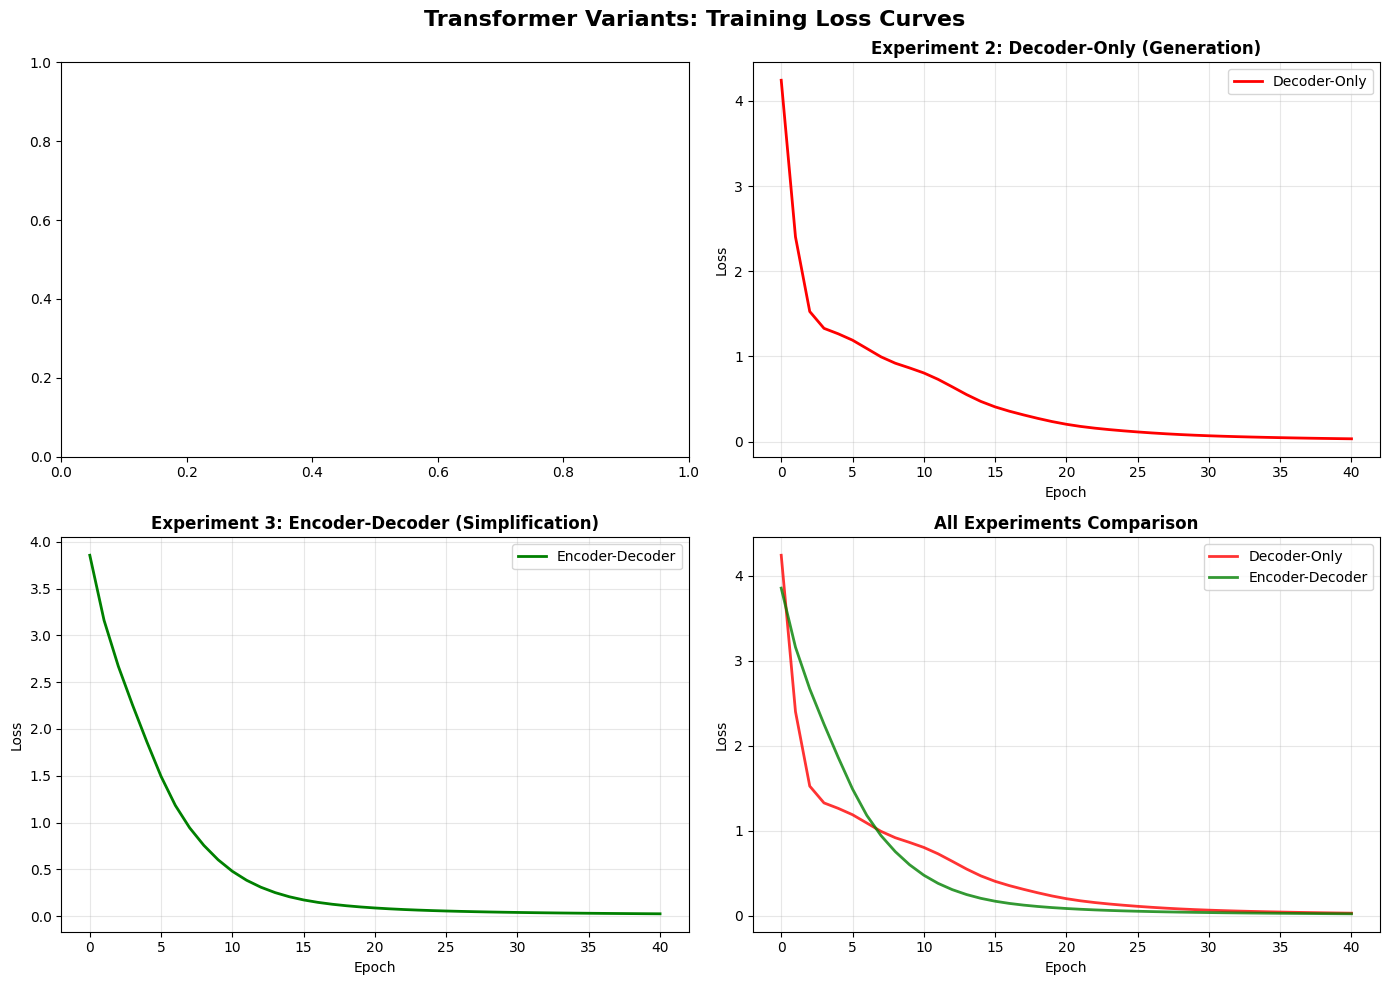

In [ ]:
run_experiments()

## Load and Prepare Triage Data

### Subtask:
Load the 'triage_questions.csv' file into a pandas DataFrame. Extract the 'triage_zone' column as input text and the 'class' column as labels. Create a new SimpleTokenizer instance using all text data (triage_zone and class) to build the vocabulary. Encode the 'triage_zone' text into numerical sequences and map the 'class' labels to numerical IDs.


In [ ]:
import pandas as pd


df_triage_loaded = pd.read_csv('/content/drive/MyDrive/triage_questions.csv')

triage_text = df_triage_loaded['class'].tolist()
triage_labels = df_triage_loaded['triage_zone'].tolist()

# Combine all text data for tokenizer vocabulary building
all_text_for_vocab = triage_text + [str(label) for label in triage_labels]

# Instantiate SimpleTokenizer with combined text data
new_tokenizer = SimpleTokenizer(all_text_for_vocab)

# Encode 'triage_zone' text
encoded_triage_text = [new_tokenizer.encode(text) for text in triage_text]

# Create a mapping from unique triage_labels to numerical IDs
unique_labels = sorted(list(set(triage_labels)))
label_to_id = {label: i for i, label in enumerate(unique_labels)}
id_to_label = {i: label for i, label in enumerate(unique_labels)}

# Convert triage_labels into numerical IDs
numerical_triage_labels = [label_to_id[label] for label in triage_labels]

print(f"Loaded {len(triage_text)} triage questions.")
print(f"Tokenizer vocabulary size: {len(new_tokenizer.vocab)}")
print(f"Sample encoded text: {encoded_triage_text[0]}")
print(f"Sample numerical label: {numerical_triage_labels[0]}")
print(f"Label to ID mapping: {label_to_id}")

Loaded 87 triage questions.
Tokenizer vocabulary size: 54
Sample encoded text: [51, 52, 38, 31, 25, 44, 26, 50, 49, 19, 35, 18, 0, 0, 0, 0, 0, 0, 0, 0]
Sample numerical label: 1
Label to ID mapping: {'Black': 0, 'Green': 1, 'Red': 2, 'Yellow': 3}


In [ ]:
vocab_size = len(new_tokenizer.vocab)
n_classes = len(unique_labels)
d_model = 128
n_layers = 2
n_heads = 4

# Convert encoded text and labels to tensors
src_data_tensor = torch.tensor(encoded_triage_text, dtype=torch.long)
labels_tensor = torch.tensor(numerical_triage_labels, dtype=torch.long)

# Initialize MedicalClassifier
model_enc_triage = MedicalClassifier(vocab_size, d_model, n_layers, n_heads, n_classes)

# Define optimizer and loss function
optimizer_triage = torch.optim.Adam(model_enc_triage.parameters(), lr=0.001)
criterion_triage = nn.CrossEntropyLoss()

# Training loop
epochs_enc_triage = []
losses_enc_triage = []
num_epochs = 50

print(f"\n--- Training Encoder-Only Model for Triage Classification ({num_epochs} epochs) ---")
for epoch in range(num_epochs):
    model_enc_triage.train() # Set model to training mode
    optimizer_triage.zero_grad()

    # Forward pass
    output = model_enc_triage(src_data_tensor)

    # Calculate loss
    loss = criterion_triage(output, labels_tensor)

    # Backward pass and optimization
    loss.backward()
    optimizer_triage.step()

    epochs_enc_triage.append(epoch)
    losses_enc_triage.append(loss.item())

    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

print("Encoder-Only model training complete.")


--- Training Encoder-Only Model for Triage Classification (50 epochs) ---
Epoch 1/50, Loss: 1.3533
Epoch 11/50, Loss: 0.0560
Epoch 21/50, Loss: 0.0045
Epoch 31/50, Loss: 0.0016
Epoch 41/50, Loss: 0.0010
Epoch 50/50, Loss: 0.0008
Encoder-Only model training complete.


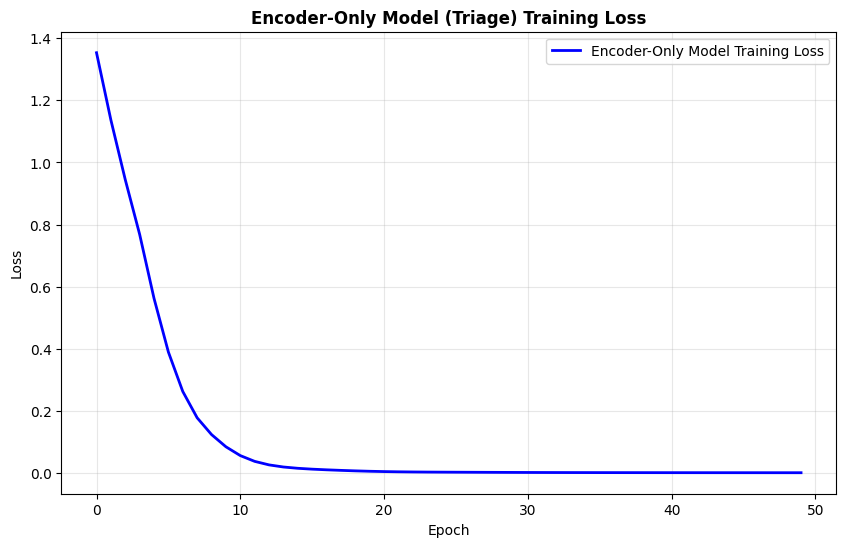

Training loss graph saved as 'encoder_only_triage_training_loss.png'


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(epochs_enc_triage, losses_enc_triage, 'b-', linewidth=2, label='Encoder-Only Model Training Loss')
plt.title('Encoder-Only Model (Triage) Training Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('encoder_only_triage_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training loss graph saved as 'encoder_only_triage_training_loss.png'")

In [ ]:
import pandas as pd
import torch

def train_gpt_on_abstracts(df, tokenizer, model, text_column='medical_abstract', slice=300, num=8):

    # 2. Select the abstract column and take a small subset (e.g., 500 rows) for CPU
    # We filter out very long abstracts to keep training fast
    abstracts = df[text_column].str.slice(0, slice).tolist()[:num]

    # 3. Tokenize
    encoded_data = [tokenizer.encode(text, max_len=128) for text in abstracts]
    input_ids = torch.tensor(encoded_data) # Shape: [500, 128]

    # 4. Training setup
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    model.train()

    print(f"Training GPT on {len(abstracts)} abstracts...")

    losses = []
    epochs = []

    for epoch in range(30):
        optimizer.zero_grad()

        # Forward pass
        # model(input_ids) returns [batch, seq_len, vocab_size]
        logits = model(input_ids)

        # Shift inputs for Next-Token Prediction
        # If input is [A, B, C, D], logits for [A, B, C] should predict [B, C, D]
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = input_ids[:, 1:].contiguous()

        # Calculate loss
        loss = torch.nn.functional.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)
        )

        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        epochs.append(epoch)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

    print("GPT Training Complete.")
    return epochs, losses

Training GPT on 2000 abstracts...
Epoch 0 | Loss: 7.5396
Epoch 10 | Loss: 0.8077
Epoch 20 | Loss: 0.4292
GPT Training Complete.


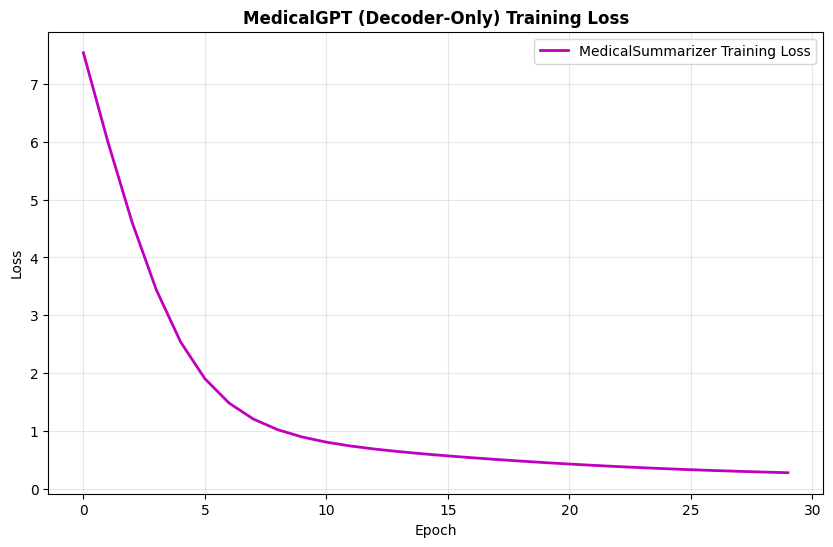

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/messages.csv')
all_text = df['message'].tolist()

tokenizer = SimpleTokenizer(all_text[:1000])
vocab_size = len(tokenizer.vocab)

model_dec = MedicalGPT(vocab_size, 128, 2, 4)

gpt_epochs, gpt_losses = train_gpt_on_abstracts(df, tokenizer, model_dec, text_column='message', slice=1000, num=2000)

plt.figure(figsize=(10, 6))
plt.plot(gpt_epochs, gpt_losses, 'm-', linewidth=2, label='MedicalSummarizer Training Loss')
plt.title('MedicalGPT (Decoder-Only) Training Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('medical_gpt_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

Training GPT on 8 abstracts...
Epoch 0 | Loss: 10.0008
Epoch 10 | Loss: 5.3307
Epoch 20 | Loss: 4.1961
GPT Training Complete.


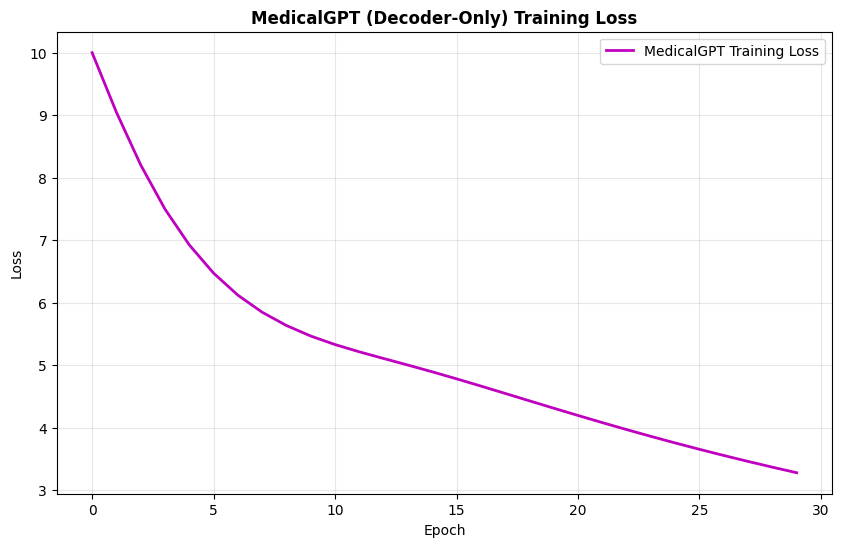

MedicalGPT training loss graph saved as 'medical_gpt_training_loss.png'


In [ ]:
# --- Example Integration ---

# Load CSV to build vocabulary
df = pd.read_csv('/content/drive/MyDrive/medical_tc_train.csv')
all_text = df['medical_abstract'].tolist()

# 1. Initialize Tokenizer with the real medical text
tokenizer = SimpleTokenizer(all_text[:1000]) # Use first 1000 rows to build vocab
vocab_size = len(tokenizer.vocab)

# 2. Initialize the Decoder-Only Model
# d_model=128, layers=2, heads=4
model_dec = MedicalGPT(vocab_size, 128, 2, 4)

# 3. Run Training and capture epochs and losses
gpt_epochs, gpt_losses = train_gpt_on_abstracts(df, tokenizer, model_dec)

# 4. Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(gpt_epochs, gpt_losses, 'm-', linewidth=2, label='MedicalGPT Training Loss')
plt.title('MedicalGPT (Decoder-Only) Training Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('medical_gpt_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

print("MedicalGPT training loss graph saved as 'medical_gpt_training_loss.png'")